In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dptel22/firms-features/sih2026_h3_daily_features.parquet


In [2]:
!apt-get update -qq && apt-get install -y osmium-tool
!pip install -q geopandas h3 scikit-learn

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)



The following additional packages will be installed:
  libboost-program-options1.74.0
The following NEW packages will be installed:
  libboost-program-options1.74.0 osmium-tool
0 upgraded, 2 newly installed, 0 to remove and 165 not upgraded.
Need to get 882 kB of archives.
After this operation, 3,863 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-program-options1.74.0 amd64 1.74.0-14ubuntu3 [311 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 osmium-tool amd64 1.14.0-1 [571 kB]
Fetched 882 kB in 1s (828 kB/s)
Selecting previously unselected package libboost-program-options1.74.0:amd64.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../libboost-program-options1.74.0_1.74.0-14ub

# Load your real feature table

In [3]:
df_daily = pd.read_parquet("/kaggle/input/datasets/dptel22/firms-features")
df_daily["h3_08"] = df_daily["h3_08"].astype(str)
print(f"df_daily: {len(df_daily):,} rows, {df_daily['h3_08'].nunique():,} unique H3 cells")
print(df_daily.columns.tolist())

df_daily: 1,718,002 rows, 921,202 unique H3 cells
['h3_08', 'acq_date', 'frp_max', 'frp_mean', 'n_detections', 'ti4_max', 'is_saturated_max', 'scan_mean', 'track_mean', 'confidence_high_any', 'daynight', 'satellite_nunique', 'is_static_land', 'is_offshore', 'frp_max_lag7', 'active_days_7d', 'frp_max_lag30', 'active_days_30d', 'active_days_90d', 'is_first_observation', 'is_labeled']


# H3 centroid table (computed once per unique cell)

In [4]:
import h3
import geopandas as gpd

unique_h3 = df_daily["h3_08"].unique()
h3_centroids = pd.DataFrame({"h3_08": unique_h3})
h3_centroids[["h3_lat", "h3_lon"]] = h3_centroids["h3_08"].apply(
    lambda c: pd.Series(h3.cell_to_latlng(c))
)
h3_gdf = gpd.GeoDataFrame(
    h3_centroids,
    geometry=gpd.points_from_xy(h3_centroids["h3_lon"], h3_centroids["h3_lat"]),
    crs="EPSG:4326",
)
print(f"H3 centroids: {len(h3_gdf):,}")

H3 centroids: 921,202


# State/UT assignment

In [5]:
import subprocess

STATE_SHP_BASE = "https://raw.githubusercontent.com/AnujTiwari/India-State-and-Country-Shapefile-Updated-Jan-2020/master/India_State_Boundary"
for ext in ["shp", "shx", "dbf", "prj", "cpg"]:
    subprocess.run(["wget", "-q", f"{STATE_SHP_BASE}.{ext}", "-O", f"/kaggle/working/state_boundary.{ext}"], check=True)

states = gpd.read_file("/kaggle/working/state_boundary.shp").to_crs(epsg=4326)
states["State_Name"] = states["State_Name"].replace(
    {"Chhattishgarh": "Chhattisgarh", "Telengana": "Telangana", "Tamilnadu": "Tamil Nadu"}
)
states = states.dissolve(by="State_Name", as_index=False)  # merges Puducherry's 4 exclaves into 1 row
states["geometry"] = states["geometry"].buffer(0)  # fixes invalid geometry left by dissolve

# H3 res-8 cells are ~0.7 km^2 — a 500m simplification tolerance cannot
# change which state a cell falls in, but cuts this shapefile's vertex
# count drastically, which is most of why the join was slow
states["geometry"] = states["geometry"].simplify(tolerance=0.005, preserve_topology=True)

assert len(states) == 36, f"Expected 36 states/UTs, got {len(states)}"
print(f"States loaded: {len(states)}")

# FAST PATH: plain sjoin+'within' uses an R-tree spatial index and is fast
# even at ~1M points. sjoin_nearest computes actual distance for EVERY
# point and is drastically slower at this scale — that was the real cause
# of the slow run, not the state count or the buffer(0) fix.
h3_gdf = gpd.sjoin(h3_gdf, states[["State_Name", "geometry"]], how="left", predicate="within")
h3_gdf = h3_gdf.drop(columns="index_right").rename(columns={"State_Name": "state"})

dup_mask = h3_gdf["h3_08"].duplicated(keep=False)
dup_ids = h3_gdf.loc[dup_mask, "h3_08"].unique()
print(f"Cells matching >1 state via 'within': {len(dup_ids):,} out of {h3_gdf['h3_08'].nunique():,} "
      f"(only these get the expensive nearest-distance treatment, not the full table)")

if len(dup_ids) > 0:
    clean = h3_gdf[~h3_gdf["h3_08"].isin(dup_ids)].copy()
    dup_points = h3_gdf[h3_gdf["h3_08"].isin(dup_ids)][["h3_08", "h3_lat", "h3_lon", "geometry"]].drop_duplicates("h3_08")
    resolved = gpd.sjoin_nearest(dup_points, states[["State_Name", "geometry"]], how="left")
    resolved = resolved.drop(columns="index_right").rename(columns={"State_Name": "state"}).drop_duplicates("h3_08")
    h3_gdf = pd.concat([clean, resolved], ignore_index=True)

assert h3_gdf["h3_08"].is_unique, (
    "still duplicated after targeted resolution — inspect dup_points/resolved "
    "above directly rather than re-running; something beyond a boundary "
    "sliver is going on"
)

unmatched = h3_gdf["state"].isna().sum()
print(f"H3 cells with no state match (offshore/coastal buffer): {unmatched:,} ({unmatched/len(h3_gdf)*100:.2f}%)")
print(f"States represented in your FIRMS data: {h3_gdf['state'].nunique()}")

States loaded: 36
Cells matching >1 state via 'within': 91 out of 921,202 (only these get the expensive nearest-distance treatment, not the full table)


/usr/local/lib/python3.12/dist-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


H3 cells with no state match (offshore/coastal buffer): 1,882 (0.20%)
States represented in your FIRMS data: 35


# WRI Global Power Plant Database

In [6]:
from sklearn.neighbors import BallTree

EARTH_RADIUS_KM = 6371.0088

wri = pd.read_csv(
    "https://raw.githubusercontent.com/wri/global-power-plant-database/master/output_database/global_power_plant_database.csv",
    low_memory=False,
)
wri_india = wri[wri["country_long"] == "India"].copy()
print(f"WRI India plants (all fuel types): {len(wri_india):,}")
print(wri_india["primary_fuel"].value_counts())

def nearest_distance_km(q_lat, q_lon, ref_lat, ref_lon):
    if len(ref_lat) == 0:
        return np.full(len(q_lat), np.nan)
    tree = BallTree(np.radians(np.column_stack([ref_lat, ref_lon])), metric="haversine")
    d, _ = tree.query(np.radians(np.column_stack([q_lat, q_lon])), k=1)
    return d[:, 0] * EARTH_RADIUS_KM

def count_within_radius(q_lat, q_lon, ref_lat, ref_lon, radius_km):
    if len(ref_lat) == 0:
        return np.zeros(len(q_lat), dtype=int)
    tree = BallTree(np.radians(np.column_stack([ref_lat, ref_lon])), metric="haversine")
    return tree.query_radius(np.radians(np.column_stack([q_lat, q_lon])), r=radius_km / EARTH_RADIUS_KM, count_only=True)

# every fuel type WRI actually has for India, not a preselected subset
for fuel in wri_india["primary_fuel"].unique():
    sub = wri_india[wri_india["primary_fuel"] == fuel]
    col_dist = f"dist_wri_{fuel.lower().replace(' ', '_')}_km"
    col_count = f"n_wri_{fuel.lower().replace(' ', '_')}_10km"
    h3_gdf[col_dist] = nearest_distance_km(h3_gdf["h3_lat"].values, h3_gdf["h3_lon"].values, sub["latitude"].values, sub["longitude"].values)
    h3_gdf[col_count] = count_within_radius(h3_gdf["h3_lat"].values, h3_gdf["h3_lon"].values, sub["latitude"].values, sub["longitude"].values, radius_km=10.0)

print("WRI feature columns added:", [c for c in h3_gdf.columns if "wri" in c])

WRI India plants (all fuel types): 1,589
primary_fuel
Solar      851
Coal       253
Hydro      233
Wind       108
Gas         68
Biomass     50
Oil         17
Nuclear      9
Name: count, dtype: int64
WRI feature columns added: ['dist_wri_solar_km', 'n_wri_solar_10km', 'dist_wri_coal_km', 'n_wri_coal_10km', 'dist_wri_wind_km', 'n_wri_wind_10km', 'dist_wri_gas_km', 'n_wri_gas_10km', 'dist_wri_hydro_km', 'n_wri_hydro_10km', 'dist_wri_biomass_km', 'n_wri_biomass_10km', 'dist_wri_oil_km', 'n_wri_oil_10km', 'dist_wri_nuclear_km', 'n_wri_nuclear_10km']


# Download nationwide OSM extract

In [7]:
import subprocess, os

pbf_path = "/kaggle/working/india-latest.osm.pbf"
if not os.path.exists(pbf_path):
    subprocess.run(["wget", "-q", "https://download.geofabrik.de/asia/india-latest.osm.pbf", "-O", pbf_path], check=True)
print(f"{pbf_path}: {os.path.getsize(pbf_path) / 1e9:.2f} GB")

/kaggle/working/india-latest.osm.pbf: 1.71 GB


# Filter OSM tags nationwide

In [8]:
PBF_FILTERED = "/kaggle/working/india_osm_filtered.osm.pbf"
GEOJSON_OUT = "/kaggle/working/india_osm_filtered.geojson"

subprocess.run([
    "osmium", "tags-filter", pbf_path,
    "nwr/landuse=industrial", "nwr/landuse=quarry", "nwr/landuse=farmland",
    "nwr/man_made=mineshaft", "nwr/man_made=adit",
    "nwr/power=plant", "nwr/power=substation", "nwr/power=generator",
    "-o", PBF_FILTERED, "--overwrite",
], check=True)

subprocess.run(["osmium", "export", PBF_FILTERED, "-o", GEOJSON_OUT, "-f", "geojson", "--overwrite"], check=True)

osm_raw = gpd.read_file(GEOJSON_OUT)
print(f"Filtered OSM features (nationwide): {len(osm_raw):,}")

Filtered OSM features (nationwide): 415,037


# OSM category distances/counts

In [9]:
CATEGORY_TAGS = {
    "industrial": ("landuse", "industrial"),
    "quarry": ("landuse", "quarry"),
    "farmland": ("landuse", "farmland"),
    "mineshaft": ("man_made", "mineshaft"),
    "adit": ("man_made", "adit"),
    "power_infra": ("power", ["plant", "substation", "generator"]),
}

for name, (key, val) in CATEGORY_TAGS.items():
    if key not in osm_raw.columns:
        h3_gdf[f"dist_osm_{name}_km"], h3_gdf[f"n_osm_{name}_5km"] = np.nan, 0
        print(f"{name}: tag key '{key}' not present in export — 0 features, check the tags-filter step")
        continue
    mask = osm_raw[key].isin(val) if isinstance(val, list) else osm_raw[key] == val
    sub = osm_raw[mask].copy()
    print(f"{name}: {len(sub):,} features")
    cent = sub.to_crs(epsg=3857).geometry.centroid.to_crs(epsg=4326)
    sub["rep_lat"], sub["rep_lon"] = cent.y, cent.x
    h3_gdf[f"dist_osm_{name}_km"] = nearest_distance_km(h3_gdf["h3_lat"].values, h3_gdf["h3_lon"].values, sub["rep_lat"].values, sub["rep_lon"].values)
    h3_gdf[f"n_osm_{name}_5km"] = count_within_radius(h3_gdf["h3_lat"].values, h3_gdf["h3_lon"].values, sub["rep_lat"].values, sub["rep_lon"].values, radius_km=5.0)

industrial: 54,521 features
quarry: 20,855 features
farmland: 213,931 features
mineshaft: 1,017 features
adit: 3 features
power_infra: 119,648 features


# Merge onto df_daily and save

In [10]:
h3_features = h3_gdf.drop(columns="geometry")
assert h3_features["h3_08"].is_unique
n_before = len(df_daily)
df_daily = df_daily.merge(h3_features, on="h3_08", how="left")
assert len(df_daily) == n_before, "merge changed row count — investigate before continuing"

df_daily.to_parquet("/kaggle/working/sih2026_h3_daily_features_with_osm_wri.parquet", index=False)
print(f"Saved. Final shape: {df_daily.shape}")

Saved. Final shape: (1718002, 52)


# Gas flare candidate check, cross-checked against WRI gas/oil proximity

In [11]:
flare_candidates = df_daily[
    (df_daily["is_saturated_max"] == 1) &
    (df_daily["active_days_90d"] >= 60)
].copy()

print(f"Flare candidates (saturation + persistence only): {len(flare_candidates):,} H3-days, "
      f"{flare_candidates['h3_08'].nunique():,} unique cells")
print("\n--- active_days_90d distribution among ALL saturated rows ---")
print(df_daily[df_daily["is_saturated_max"] == 1]["active_days_90d"].describe())

# Saturation + persistence alone can't tell a flare apart from a coal kiln,
# brick kiln, or large industrial furnace — anything hot and continuous
# matches this rule. Proximity to a known WRI gas/oil plant is the actual
# discriminator, and you already computed dist_wri_gas_km / dist_wri_oil_km
# in Cell 4 — use it here instead of treating the raw rule as the label.
assert "dist_wri_gas_km" in df_daily.columns, "run Cell 4 before this cell"

near_wri = (
    (df_daily.loc[flare_candidates.index, "dist_wri_gas_km"] < 5) |
    (df_daily.loc[flare_candidates.index, "dist_wri_oil_km"] < 5)
)
flare_confirmed = flare_candidates[near_wri]
flare_unexplained = flare_candidates[~near_wri]

print(f"\nConfirmed (within 5km of a WRI gas/oil plant): {flare_confirmed['h3_08'].nunique():,} unique cells")
print(f"Unexplained (saturated + persistent, no nearby WRI plant — likely kilns, "
      f"furnaces, or undocumented flares, worth a manual look later): "
      f"{flare_unexplained['h3_08'].nunique():,} unique cells")

Flare candidates (saturation + persistence only): 443 H3-days, 41 unique cells

--- active_days_90d distribution among ALL saturated rows ---
count    61610.00000
mean         1.19565
std          7.11881
min          0.00000
25%          0.00000
50%          0.00000
75%          1.00000
max         90.00000
Name: active_days_90d, dtype: float64

Confirmed (within 5km of a WRI gas/oil plant): 5 unique cells
Unexplained (saturated + persistent, no nearby WRI plant — likely kilns, furnaces, or undocumented flares, worth a manual look later): 36 unique cells


# THE ACTUAL DELIVERABLE

In [12]:
state_summary = df_daily.groupby("state").agg(
    n_h3_days=("h3_08", "count"),
    n_unique_cells=("h3_08", "nunique"),
    industrial_cells=("dist_osm_industrial_km", lambda x: (x < 5).sum()),
    quarry_cells=("dist_osm_quarry_km", lambda x: (x < 5).sum()),
    farmland_cells=("dist_osm_farmland_km", lambda x: (x < 5).sum()),
    power_infra_cells=("dist_osm_power_infra_km", lambda x: (x < 5).sum()),
).reset_index()

# add every WRI fuel column that actually got created in Cell 4 — not a fixed preset list
wri_cols = [c for c in df_daily.columns if c.startswith("n_wri_") and c.endswith("_10km")]
for col in wri_cols:
    state_summary[col.replace("n_wri_", "wri_").replace("_10km", "")] = (
        df_daily.groupby("state")[col].apply(lambda x: (x > 0).sum()).values
    )

# gas flare candidates per state — both the raw rule and the WRI-confirmed subset from Cell 9
flare_by_state = flare_candidates.groupby("state")["h3_08"].nunique().rename("flare_candidate_cells")
flare_confirmed_by_state = flare_confirmed.groupby("state")["h3_08"].nunique().rename("flare_confirmed_cells")
state_summary = state_summary.merge(flare_by_state, on="state", how="left").fillna({"flare_candidate_cells": 0})
state_summary = state_summary.merge(flare_confirmed_by_state, on="state", how="left").fillna({"flare_confirmed_cells": 0})

pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
print(state_summary.sort_values("n_h3_days", ascending=False).to_string(index=False))

state_summary.to_csv("/kaggle/working/state_evidence_table.csv", index=False)
print("\nSaved: /kaggle/working/state_evidence_table.csv")

                                   state  n_h3_days  n_unique_cells  industrial_cells  quarry_cells  farmland_cells  power_infra_cells  wri_solar  wri_coal  wri_wind  wri_gas  wri_hydro  wri_biomass  wri_oil  wri_nuclear  flare_candidate_cells  flare_confirmed_cells
                          Madhya Pradesh     268613          142173             23159         26505           19489              56225       8037     11802       655      381       1994          208        0            0                    1.0                    0.0
                            Chhattisgarh     184402           80329             36703         19114           17432              45372       3027     20122         0        0        154            0        0            0                    6.0                    0.0
                             Maharashtra     166883          105610             36701         22423           30973              49983       5910      8812      3676     1610       5999         3189 

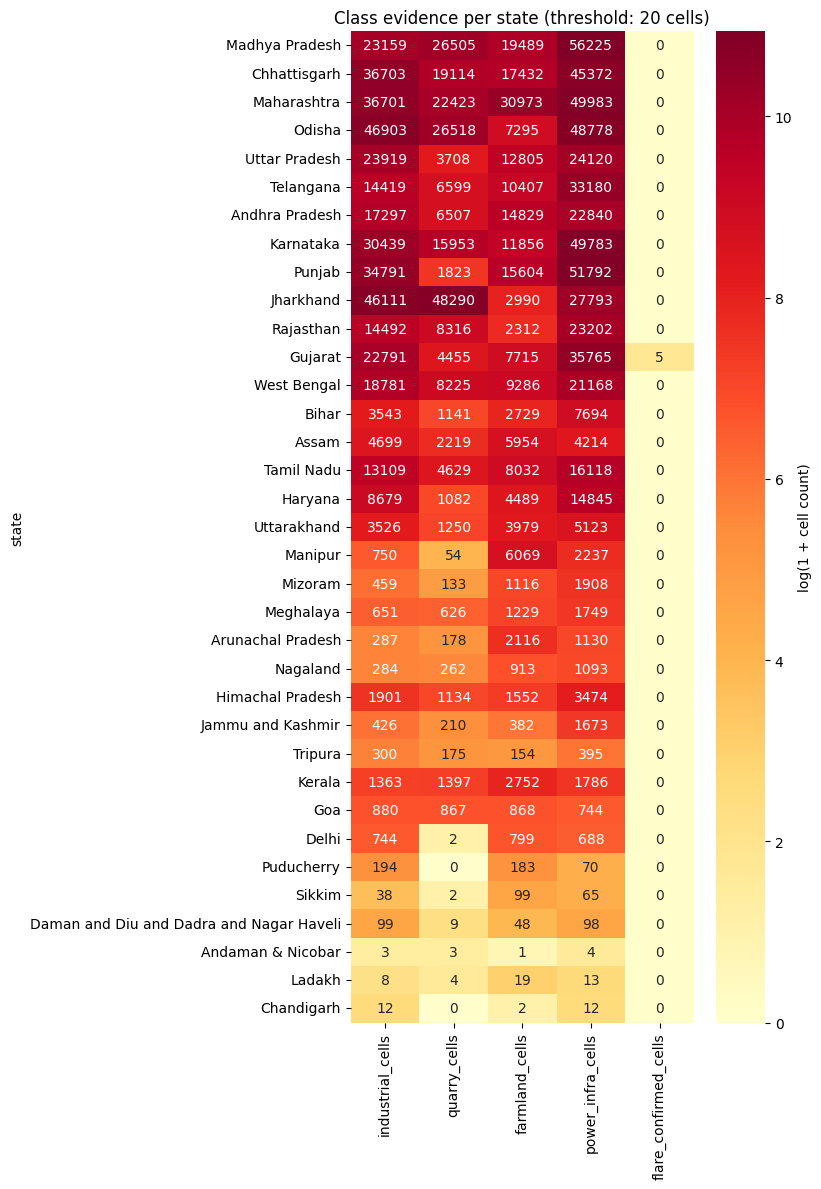

In [13]:
CLASS_COLS = ["industrial_cells", "quarry_cells", "farmland_cells", "power_infra_cells", "flare_confirmed_cells"]
MIN_EVIDENCE = 20  # cells — arbitrary threshold, adjust and re-run if the table looks wrong at this cutoff

state_summary["classes_present"] = (state_summary[CLASS_COLS] >= MIN_EVIDENCE).sum(axis=1)
ranked = state_summary.sort_values(["classes_present", "n_h3_days"], ascending=False).reset_index(drop=True)

# --- Option A: color-coded table, renders directly in the notebook, no extra libraries ---
# log1p because raw counts span orders of magnitude (a state can have 3
# quarries and another 3,000 farmland cells) — without it, one big column
# washes out the color scale for every other column
import numpy as np

display_cols = ["state", "n_h3_days", "classes_present"] + CLASS_COLS
styled = (
    ranked[display_cols]
    .style
    .background_gradient(subset=CLASS_COLS, cmap="YlOrRd", gmap=np.log1p(ranked[CLASS_COLS]))
    .background_gradient(subset=["classes_present"], cmap="Greens")
    .format(precision=0)
)
styled  # in Kaggle/Jupyter, just leave this as the last line of the cell to render it

# --- Option B: matplotlib heatmap, better if you want a static image for the report/slides ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    np.log1p(ranked.set_index("state")[CLASS_COLS]),
    annot=ranked.set_index("state")[CLASS_COLS],  # show real counts, color by log scale
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={"label": "log(1 + cell count)"},
    ax=ax,
)
ax.set_title(f"Class evidence per state (threshold: {MIN_EVIDENCE} cells)")
plt.tight_layout()
plt.savefig("/kaggle/working/state_class_heatmap.png", dpi=150)
plt.show()

In [14]:
def check_partition_support(train_states, testA_states, testB_states, summary,
                             class_cols=CLASS_COLS, min_train=100, min_test=30):
    """Hard-constraint check against REAL counts. Does not choose states for you —
    plug in candidates from Cell 11's table and see if they actually survive."""
    def totals(states):
        return summary[summary["state"].isin(states)][class_cols].sum()

    train_tot, testA_tot, testB_tot = totals(train_states), totals(testA_states), totals(testB_states)
    result = {
        "train_ok": bool((train_tot >= min_train).all()),
        "testA_ok": bool((testA_tot >= min_test).all()),
        "testB_ok": bool((testB_tot >= min_test).all()),
    }
    result["valid"] = all(result.values())

    for label, states, tot in [("train", train_states, train_tot), ("testA", testA_states, testA_tot), ("testB", testB_states, testB_tot)]:
        print(f"\n{label}: {list(states)}")
        print(tot.to_string())
    print(f"\nVALID: {result['valid']}", result)
    return result

# EXAMPLE CALL ONLY — replace with whatever combination Cell 11's sorted table actually points toward.
# Nothing here decides the split; it only tells you whether a candidate split survives contact with real numbers.
# check_partition_support(["StateA", "StateB"], ["StateC"], ["StateD", "StateE"], state_summary)